WELCOME TO SCIKIT LEARN

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn._config import set_config
from sklearn.linear_model import LogisticRegression

Accuracy: 93.65
Recall: 94.44


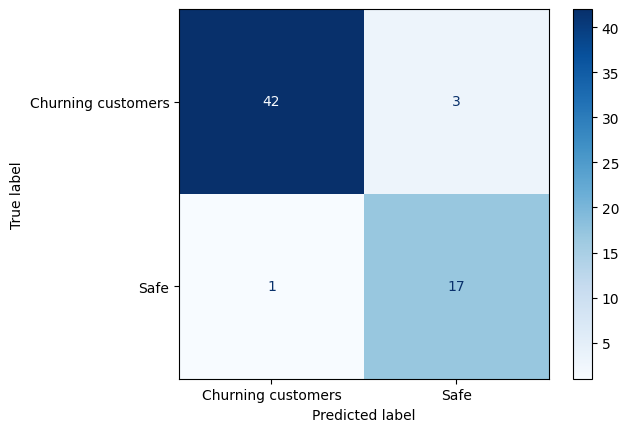

              precision    recall  f1-score   support

        Safe       0.98      0.93      0.95        45
    Churning       0.85      0.94      0.89        18

    accuracy                           0.94        63
   macro avg       0.91      0.94      0.92        63
weighted avg       0.94      0.94      0.94        63



In [28]:
set_config(transform_output="pandas")

df = pd.read_csv("pandas.csv")

X = df.drop(columns=["churn"])
y = df["churn"]

# train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# preprocess data
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['str', 'category']).columns

preprocess = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), numeric_features),
        ("encoder", OneHotEncoder(sparse_output=False), categorical_features)
    ],
)

# create pipeline
pipe = Pipeline([("prep", preprocess), ("model", LogisticRegression(random_state=42))])

model = GridSearchCV(
    estimator=pipe,
    param_grid={
        'model__class_weight': [{0: 3, 1: 10}]
    },
    scoring=['precision', 'recall', 'f1'],
    refit='recall',
    cv=5,
)

# # train model
model.fit(X_train, y_train)

# # evaluate model
model_predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, model_predictions)
print(f"Accuracy: {accuracy * 100:.2f}")

recall = recall_score(y_test, model_predictions)
print(f"Recall: {recall * 100:.2f}")

cm = confusion_matrix(y_test, model_predictions)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Churning customers", "Safe"]
)

disp.plot(cmap="Blues")
plt.show()

classify = classification_report(y_test, model_predictions, target_names=['Safe', 'Churning'])
print(classify)


RANDOM FOREST

Score: 95.24
Recall: 88.89
              precision    recall  f1-score   support

        Safe       0.96      0.98      0.97        45
    Churning       0.94      0.89      0.91        18

    accuracy                           0.95        63
   macro avg       0.95      0.93      0.94        63
weighted avg       0.95      0.95      0.95        63



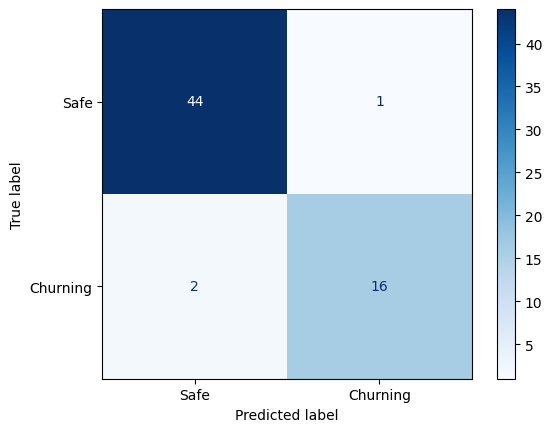

                                    Feature  Importance
1             encoder__contract_type_yearly    0.296117
8                  remainder__support_calls    0.286136
0            encoder__contract_type_monthly    0.156630
7                  remainder__tenure_months    0.091133
5                            remainder__age    0.075597
6                  remainder__monthly_spend    0.067591
4  encoder__payment_method_Electronic Check    0.020072
2     encoder__payment_method_Bank Transfer    0.004758
3       encoder__payment_method_Credit Card    0.001967


In [ ]:
set_config(transform_output="pandas")

df = pd.read_csv("pandas.csv")

X = df.drop(columns=["churn"])
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

categorical_features = X.select_dtypes(include=["str", "category"]).columns

preprocess = ColumnTransformer(
    transformers=[
        ("encoder", OneHotEncoder(sparse_output=False), categorical_features)
    ],
    remainder="passthrough",
)

# create pipeline
pipe = Pipeline(
    [("prep", preprocess), ("model", RandomForestClassifier(random_state=42))]
)

# grid search cv
second_model = GridSearchCV(
    estimator=pipe,
    param_grid={
        "model__n_estimators": [5, 15],
        "model__max_depth": [5],
        "model__class_weight": [{0: 1, 1: 10}],
    },
    cv=5,
    scoring=["recall", "precision"],
    refit="recall",
)

second_model.fit(X_train, y_train)

y_pred = second_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Score: {accuracy * 100:.2f}")

recal = recall_score(y_test, y_pred)
print(f"Recall: {recal * 100:.2f}")

classify = classification_report(y_test, y_pred, target_names=['Safe', 'Churning'])
print(classify)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Safe", "Churning"]
)

disp.plot(cmap="Blues")
plt.show()

# 1. Grab the winning FITTED pipeline
best_pipe = second_model.best_estimator_

# 2. Get names from the FITTED preprocessor
feature_names = best_pipe.named_steps['prep'].get_feature_names_out()

# 3. Get importances from the FITTED model (Random Forest)
importances = best_pipe.named_steps['model'].feature_importances_

# 4. Combine into a DataFrame and print
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort so the "MVP" features are at the top
print(importance_df.sort_values(by='Importance', ascending=False))
